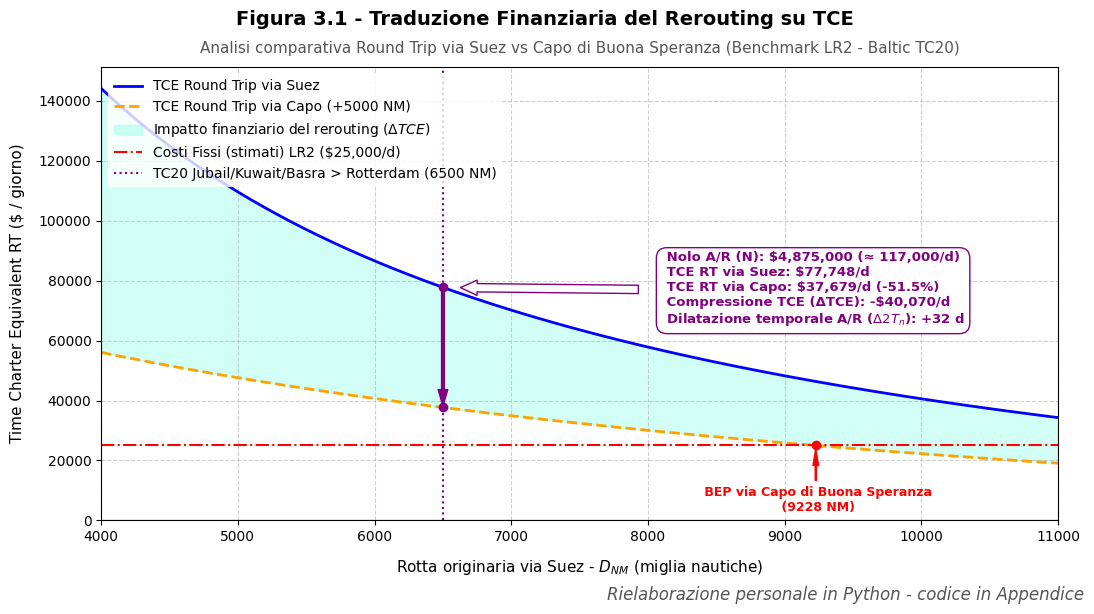

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# starting data
S_lr2 = 13.0  # kts speed
fc_d = 32.0  # bunker mt/d
p_fuel = 640  # bunker price (ifo380 fujairah)
e_factor = 3.114  #co2 emission factor eq
p_co2 = 80  #co2 price

# expenses
bunker_cost_daily = fc_d * (p_fuel + (e_factor * p_co2))
costi_fissi_daily = 25000  #daily capex + opex

# course
D_suez_ref = 6500  #suez distance
delta_D = 5000  #extra nmiles
CD_suez = 450000  #suez toll

# duration days
Tn_suez_ref = D_suez_ref / (S_lr2 * 24)  #one way suez
Tn_suez_RT = 2 * Tn_suez_ref  #round trip suez

Tn_gh_ref = (D_suez_ref + delta_D) / (S_lr2 * 24)  #one way cape
Tn_gh_RT = 2 * Tn_gh_ref  #round trip cape

# final fixture
# we should go lumpsum but we keep daily*days
rate_daily_target = 117000  #baltic tc20
N_fixed = rate_daily_target * Tn_suez_RT  #fake lumpsum

# tce
tce_suez_ref = ((N_fixed - CD_suez) / Tn_suez_RT) - bunker_cost_daily
tce_gh_ref = (N_fixed / Tn_gh_RT) - bunker_cost_daily

pct_change = ((tce_gh_ref - tce_suez_ref) / tce_suez_ref) * 100
delta_tce = tce_suez_ref - tce_gh_ref
delta_Tn_RT = Tn_gh_RT - Tn_suez_RT

# distance function equations
distanze_suez = np.linspace(4000, 11000, 300)
Tn_suez_curve_RT = 2 * (distanze_suez / (S_lr2 * 24))
Tn_gh_curve_RT = 2 * ((distanze_suez + delta_D) / (S_lr2 * 24))

tce_suez_curve = ((N_fixed - CD_suez) / Tn_suez_curve_RT) - bunker_cost_daily
tce_gh_curve = (N_fixed / Tn_gh_curve_RT) - bunker_cost_daily

# bep
Tn_be_suez_RT = (N_fixed - CD_suez) / (costi_fissi_daily + bunker_cost_daily)
D_be_suez = (Tn_be_suez_RT / 2) * S_lr2 * 24

Tn_be_gh_RT = N_fixed / (costi_fissi_daily + bunker_cost_daily)
D_be_gh = ((Tn_be_gh_RT / 2) * S_lr2 * 24) - delta_D

# graph
plt.figure(figsize=(11, 6))

plt.plot(
    distanze_suez,
    tce_suez_curve,
    label="TCE Round Trip via Suez",
    color="blue",
    linewidth=2,
)
plt.plot(
    distanze_suez,
    tce_gh_curve,
    label=f"TCE Round Trip via Capo (+{delta_D:.0f} NM)",
    color="#ffa200",
    linestyle="--",
    linewidth=2,
)

plt.fill_between(
    distanze_suez,
    tce_suez_curve,
    tce_gh_curve,
    color="#4dffd8",
    alpha=0.25,
    label="Impatto finanziario del rerouting ($ΔTCE$)",
)

# fixed costs line
plt.axhline(
    y=costi_fissi_daily,
    color="red",
    linestyle="-.",
    linewidth=1.5,
    label=f"Costi Fissi (stimati) LR2 (${costi_fissi_daily:,.0f}/d)",
)

# bep points
if 4000 <= D_be_gh <= 11000:
    plt.plot(D_be_gh, costi_fissi_daily, "ro", markersize=6)
    plt.annotate(
        f" BEP via Capo di Buona Speranza\n ({D_be_gh:.0f} NM)",
        xy=(D_be_gh, costi_fissi_daily),
        xytext=(D_be_gh, costi_fissi_daily - 22000),
        arrowprops=dict(
            facecolor="red", edgecolor="red", shrink=0.08, width=0.8, headwidth=4
        ),
        fontsize=9,
        fontweight="bold",
        color="red",
        ha="center",
    )

if 4000 <= D_be_suez <= 11000:
    plt.plot(D_be_suez, costi_fissi_daily, "ro", markersize=6)
    plt.annotate(
        f" BEP via Suez\n ({D_be_suez:.0f} NM)",
        xy=(D_be_suez, costi_fissi_daily),
        xytext=(D_be_suez, costi_fissi_daily + 12000),
        arrowprops=dict(
            facecolor="red", edgecolor="red", shrink=0.08, width=0.8, headwidth=4
        ),
        fontsize=8,
        fontweight="bold",
        color="red",
        ha="right",
    )

# tce deviation line
plt.axvline(
    x=D_suez_ref,
    color="purple",
    linestyle=":",
    linewidth=1.5,
    label=f"TC20 Jubail/Kuwait/Basra > Rotterdam ({D_suez_ref:.0f} NM)",
)

# tce deviation arrow
plt.annotate(
    "",
    xy=(D_suez_ref, tce_gh_ref),
    xytext=(D_suez_ref, tce_suez_ref),
    arrowprops=dict(
        facecolor="purple",
        edgecolor="purple",
        width=2,
        headwidth=7,
        shrink=0.01,
    ),
)

plt.plot(
    [D_suez_ref, D_suez_ref],
    [tce_suez_ref, tce_gh_ref],
    "o",
    color="purple",
    markersize=6,
)

# tce suez point
x_point = D_suez_ref
y_point = tce_suez_ref

# databox
x_box = x_point + 1200
y_box = y_point - 5000

plt.annotate(
    f" Nolo A/R (N): ${N_fixed:,.0f} (≈ {rate_daily_target:,.0f}/d)\n"
    f" TCE RT via Suez: ${tce_suez_ref:,.0f}/d\n"
    f" TCE RT via Capo: ${tce_gh_ref:,.0f}/d ({pct_change:.1f}%)\n"
    f" Compressione TCE (ΔTCE): -${delta_tce:,.0f}/d\n"
    f" Dilatazione temporale A/R ($Δ2T_n$): +{delta_Tn_RT:.0f} d",
    xy=(D_suez_ref, tce_suez_ref),
    xytext=(D_suez_ref + 1600, tce_suez_ref - 12000),
    arrowprops=dict(facecolor="white", shrink=0.08, width=6, headwidth=11,edgecolor="purple"),
    fontsize=9.5,
    fontweight="bold",
    color="purple",
    bbox=dict(boxstyle="round, pad=0.4, rounding_size=0.8", facecolor="white", edgecolor="purple"),
)

# graph title & data
plt.suptitle('Figura 3.1 - Traduzione Finanziaria del Rerouting su TCE', fontsize=14, fontweight='bold', y=0.97)
plt.title('Analisi comparativa Round Trip via Suez vs Capo di Buona Speranza (Benchmark LR2 - Baltic TC20)', fontsize=11, color='#555555', pad=10)
plt.xlabel('Rotta originaria via Suez - $D_{NM}$ (miglia nautiche)', fontsize=11, labelpad=10)
plt.ylabel('Time Charter Equivalent RT ($ / giorno)', fontsize=11, labelpad=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(frameon=True, facecolor='white', edgecolor='none', loc='upper left')
plt.axhline(0, color="black", linewidth=0.8, linestyle="-")

# graphic limitations
plt.xlim(4000, 11000)
plt.gca().set_xmargin(0)
plt.ylim(0)

# subtitle
plt.figtext(0.99, -0.02, 'Rielaborazione personale in Python - codice in Appendice',
            ha='right', va='bottom', fontsize=12, color='#555555', fontstyle='italic')

plt.tight_layout()

# export pdf
plt.savefig('grafico_tc20.pdf', format='pdf', bbox_inches='tight')
plt.show()